# Advanced Time-Frequency Analysis

## Part of the open_dvm Toolbox

Building on the foundational TFR techniques from `03_tfr_analysis.ipynb`, this tutorial explores advanced time-frequency analysis methods: wavelet parameter selection, alternative decomposition methods, and multi-subject statistical testing.

## Learning Objectives

After completing this tutorial, you will:

- **Understand wavelet parameter trade-offs** — How cycle ranges affect temporal vs. frequency resolution
- **Compare decomposition methods** — Morlet wavelets vs. Hilbert transform
- **Aggregate effects across subjects** — Build grand-average time-frequency results
- **Apply statistical testing** — FDR-corrected significance testing on time-frequency data

**Prerequisites:** Complete `03_tfr_analysis.ipynb` first to understand basic TFR computation, baseline correction, and lateralization analysis.

## Overview

### Key Steps

1. **Wavelet parameter exploration** — How temporal-frequency resolution trade-offs affect your results
2. **Wavelet vs. Hilbert comparison** — When to use alternative decomposition methods
3. **Multi-subject condition comparisons** — Aggregating across subjects and testing statistical significance

## Section 1: Setup and Configuration

### 1.1 Import Required Libraries

In [1]:
# Enable inline plotting and suppress warnings
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
import os
from IPython.display import display

# Add open_dvm to path
sys.path.insert(0, '/Users/dvm/Documents/DvM')

# Import analysis tools
import warnings
warnings.filterwarnings('ignore')

from open_dvm.analysis import TFR
from open_dvm.support.FolderStructure import FolderStructure
from open_dvm.visualization.plot import plot_tfr_timecourse

print("✓ All imports successful!")

✓ All imports successful!


### 1.2 Load Preprocessed Data with Eye-Tracking Quality Control

In [2]:
# ============================================
# Configuration: Change these for your data
# ============================================
project_folder = '/Users/dvm/Library/CloudStorage/OneDrive-VrijeUniversiteitAmsterdam/projects/openDvM'
os.chdir(project_folder)

# Subject number (1-7 in this dataset)
sj = 2

# Eye-tracking quality control
eye_dict = {
    'use_tracker': True,  # Enable eye-tracking exclusion
    'window_oi': (0, 0.3),  # Window: 0-300 ms post-stimulus
    'angle_thresh': 1,  # Threshold: 1 degree visual angle
    'viewing_dist': 70,  # Viewing distance (cm)
    'screen_res': (1920, 1080),  # Screen resolution (pixels)
    'screen_h': 29,  # Screen height (cm)
    'drift_correct': (-0.2, 0)  # Drift correction window
}

# Load preprocessed data
df, epochs = FolderStructure().load_processed_epochs(
    sj, 'ses_01_main', 'main', eye_dict
)

print(f'✓ Subject {sj} data loaded')
print(f'  • {len(epochs)} trials')
print(f'  • {epochs.info["nchan"]} channels')
print(f'  • Sampling rate: {epochs.info["sfreq"]} Hz')

Reading /Users/dvm/Library/CloudStorage/OneDrive-VrijeUniversiteitAmsterdam/projects/openDvM/eeg/processed/sub_02_ses_01_main-epo.fif ...
    Found the data of interest:
        t =    -699.22 ...    1000.00 ms
        0 CTF compensation matrices available
Adding metadata with 19 columns
2902 matching events found
No baseline correction applied
0 projection items activated
Eye channel is not specified in eyedict, using HEOG as default
4 trials missing eyetracking
data (used eog instead)
Eye exclusion info saved in preprocessing file (session 01)
✓ Subject 2 data loaded
  • 2148 trials
  • 39 channels
  • Sampling rate: 512.0 Hz


---

## Section 2: Wavelet Parameter Exploration

**Research Question**: How do wavelet parameters affect the temporal-frequency resolution trade-off? Do more cycles improve frequency resolution while sacrificing temporal resolution?

**Key insight**: The number of Morlet wavelet cycles determines resolution:
- **Fewer cycles** (3-8) — Better temporal precision but noisier frequency estimates
- **Standard** (3-10) — Balanced trade-off (default recommendation)
- **More cycles** (4-12) — Better frequency selectivity but smeared in time

**Why this matters**: For questions requiring precise temporal localization (e.g., event-related components), fewer cycles are better. For frequency-specific hypotheses (e.g., narrowband oscillations), more cycles improve selectivity.

In [3]:
# Try different wavelet cycle ranges
cycle_configs = {
    'Fast (3-8)': (3, 8),
    'Standard (3-10)': (3, 10),
    'Slow (4-12)': (4, 12)
}

tfr_cycles = {}

print('Computing TFR with different wavelet cycle ranges...')

for config_name, cycles in cycle_configs.items():
    tfr_temp = TFR(
        sj=sj,
        epochs=epochs,
        df=df,
        min_freq=4,                # Start from theta band (4 Hz)
        max_freq=40,               # Up to low gamma (40 Hz)
        num_frex=25,               # 25 frequencies between 4-40 Hz
        cycle_range=cycles,        # Current cycle configuration under comparison (loop variable)
        freq_scaling='log',        # Logarithmic frequency spacing
        baseline=(-0.2, 0),        # Baseline period: -200 to 0 ms pre-stimulus
        base_method='trial_spec',  # Trial-specific baseline correction
        downsample=2               # Downsample by factor of 2
    )
    
    tfr_result = tfr_temp.condition_tfrs(
        pos_labels=None,                      # No position-based lateralization for this comparison
        cnds={'block_type': ['localizer']},   # Localizer trials only
        elec_oi='all',                        # Average across all electrodes
        window_oi=(-0.2, 0.5),                # Analysis window: -200 to 500 ms
        f_name=f'cycles_{config_name}'        # Save per cycle configuration for later reload
    )
    
    tfr_cycles[config_name] = tfr_result['localizer'].data.mean(axis=0)
    print(f'  ✓ cycles {cycles}')

# Extract times and freqs for visualization
times = tfr_result['localizer'].times
freqs = tfr_result['localizer'].freqs

print('\n✓ TFR computation with different cycle ranges complete')

Computing TFR with different wavelet cycle ranges...
No topography info specified. For lateralization analysis, it is assumed as if all stimuli of interest are presented right (i.e., left  hemifield
Decomposing condition 1: localizer 

saving tfr for condition: localizerannels
Overwriting existing file.
  ✓ cycles (3, 8)
No topography info specified. For lateralization analysis, it is assumed as if all stimuli of interest are presented right (i.e., left  hemifield
Decomposing condition 1: localizer 

saving tfr for condition: localizerannels
Overwriting existing file.
  ✓ cycles (3, 10)
No topography info specified. For lateralization analysis, it is assumed as if all stimuli of interest are presented right (i.e., left  hemifield
Decomposing condition 1: localizer 

saving tfr for condition: localizerannels
Overwriting existing file.
  ✓ cycles (4, 12)

✓ TFR computation with different cycle ranges complete


No conditions specified. Using first condition in tfr
not enough colors specified. Using default colors
Times converted from seconds to milliseconds
No conditions specified. Using first condition in tfr
not enough colors specified. Using default colors
Times converted from seconds to milliseconds
No conditions specified. Using first condition in tfr
not enough colors specified. Using default colors
Times converted from seconds to milliseconds


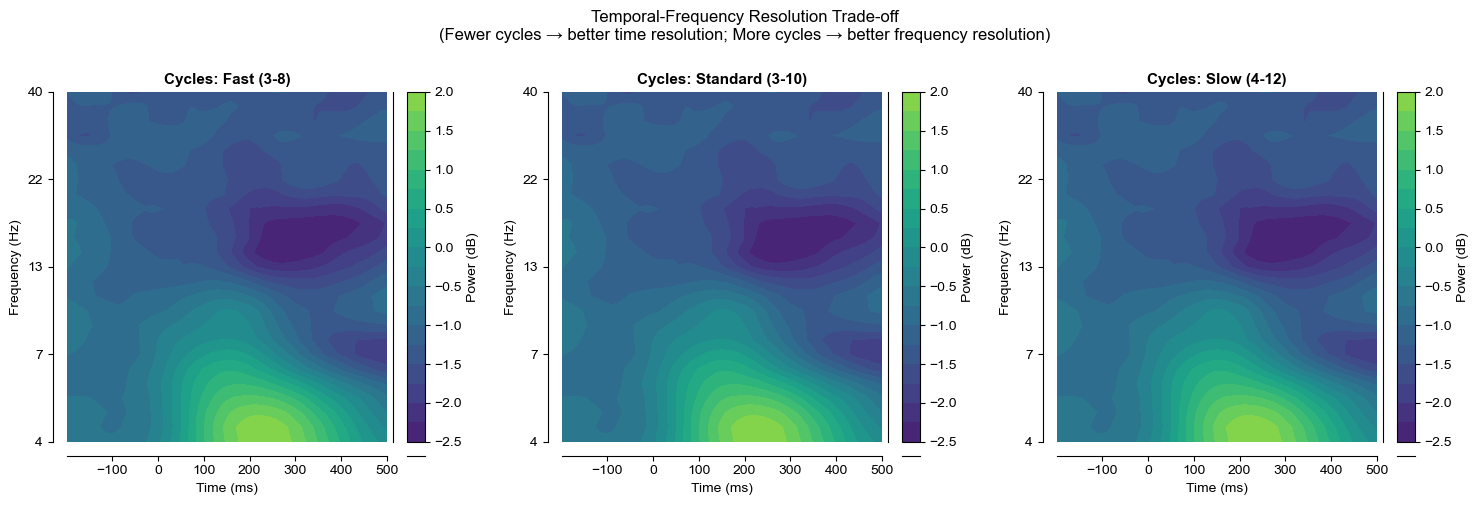

✓ Wavelet cycle comparison complete

Key observations:
  • Fast (3-8): Sharper temporal boundaries, noisier frequency estimates
  • Standard (3-10): Balanced approach (recommended default)
  • Slow (4-12): Better frequency separation, broader temporal smearing


In [4]:
# Compare wavelet cycle ranges using built-in plotting
# Prepare TFR objects for each cycle configuration
tfr_comparison = {}

for config_name in tfr_cycles.keys():
    # Create a minimal MNE-like object for plotting
    # Store the pre-computed power data with times/freqs from the first TFR result
    tfr_comparison[config_name] = tfr_result['localizer']

# Create figure with subplots for each cycle configuration
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plt.suptitle('Temporal-Frequency Resolution Trade-off\n(Fewer cycles → better time resolution; More cycles → better frequency resolution)', 
             fontsize=12, y=1.00)

for idx, (config_name, tfr_obj) in enumerate(tfr_comparison.items()):
    plt.sca(axes[idx])
    
    # Use built-in plotting function
    plot_tfr_timecourse(
        tfr={config_name: tfr_obj},
        elec_oi=list(tfr_obj.ch_names),
        timecourse='2d',
        contour=True,
        levels=20,
        cmap='viridis',
        vmin=-3,
        vmax=3,
        onset_times=[0]
    )
    
    plt.title(f'Cycles: {config_name}', fontsize=11, fontweight='bold')

plt.tight_layout()
display(fig)
plt.close()

print("✓ Wavelet cycle comparison complete")
print("\nKey observations:")
print("  • Fast (3-8): Sharper temporal boundaries, noisier frequency estimates")
print("  • Standard (3-10): Balanced approach (recommended default)")
print("  • Slow (4-12): Better frequency separation, broader temporal smearing")

---

## Section 3: Wavelet vs. Hilbert Comparison

**Research Question**: When should you use alternative time-frequency decomposition methods? How do Morlet wavelets compare to Hilbert transforms?

**Context**:
- **Morlet wavelets** — Standard in TFR; provides good time-frequency localization with controlled trade-offs
- **Hilbert transform** — Faster; assumes narrowband filtering is done separately (e.g., with butterworth); provides instantaneous amplitude/phase
- **Multi-taper methods** — Optimal for static spectra; less useful for event-related TFR

### Your Task
In the cells below, implement a comparison of:
1. **Morlet wavelet decomposition** (code template provided)
2. **Hilbert transform on narrowband-filtered data** (requires implementation)
3. **Visualization using `plot_tfr_timecourse`** (use built-in plotting, not manual matplotlib)

**Hints**:
- Use `scipy.signal.hilbert()` for analytic signal
- Filter with `scipy.signal.butter()` + `scipy.signal.sosfilt()` for different frequency bands
- Extract instantaneous amplitude: `np.abs(analytic_signal)`
- **Visualization**: Use `plot_tfr_timecourse(timecourse='2d', contour=True)` for both methods (no manual plt.contourf)

In [5]:
# Morlet wavelet TFR computation
tfr_morlet_obj = TFR(
    sj=sj,
    epochs=epochs,
    df=df,
    min_freq=4,                # Start from theta band (4 Hz)
    max_freq=40,               # Up to low gamma (40 Hz)
    num_frex=25,               # 25 frequencies between 4-40 Hz
    cycle_range=(3, 10),       # Standard wavelet cycles (balanced resolution trade-off)
    freq_scaling='log',        # Logarithmic frequency spacing
    baseline=(-0.2, 0),        # Baseline period: -200 to 0 ms pre-stimulus
    method='wavelet',          # Morlet wavelet decomposition (compared against Hilbert below)
    base_method='cnd_spec',    # Condition-specific baseline correction
    downsample=2               # Downsample by factor of 2
)

tfr_morlet = tfr_morlet_obj.condition_tfrs(
    pos_labels=None,                       # No position-based lateralization for this comparison
    cnds={'block_type': ['main']},         # Main task trials only
    elec_oi=['Fp1', 'Fp2', 'AF3', 'AF4'],  # Frontal electrodes
    window_oi=(-0.2, 0.5),                 # Analysis window: -200 to 500 ms
    f_name='wavelet_tfr'                   # Analysis identifier for saved output
)

print("✓ Morlet (Wavelet) TFR computed")
print(f"  • Data shape: {tfr_morlet['main'].data.shape}")

# Reuse the same object for the Hilbert method rather than constructing a
# new TFR instance: changing `.method` after construction is safe here --
# frequency-band-dependent internals regenerate lazily from the new method
# the next time condition_tfrs() is called.
tfr_morlet_obj.method = 'hilbert'
tfr_hilbert = tfr_morlet_obj.condition_tfrs(
    pos_labels=None,                       # No position-based lateralization for this comparison
    cnds={'block_type': ['main']},         # Main task trials only
    elec_oi=['Fp1', 'Fp2', 'AF3', 'AF4'],  # Frontal electrodes
    window_oi=(-0.2, 0.5),                 # Analysis window: -200 to 500 ms
    f_name='hilbert_tfr'                   # Analysis identifier for saved output
)

print("✓ Hilbert (Analytic Signal) TFR computed")
print(f"  • Data shape: {tfr_hilbert['main'].data.shape}")

No topography info specified. For lateralization analysis, it is assumed as if all stimuli of interest are presented right (i.e., left  hemifield
Decomposing condition 1: main 

saving tfr for condition: main channels
Overwriting existing file.
✓ Morlet (Wavelet) TFR computed
  • Data shape: (4, 25, 180)
No topography info specified. For lateralization analysis, it is assumed as if all stimuli of interest are presented right (i.e., left  hemifield
Decomposing condition 1: main 

saving tfr for condition: main channels
Overwriting existing file.
✓ Hilbert (Analytic Signal) TFR computed
  • Data shape: (4, 25, 180)


No conditions specified. Using first condition in tfr
not enough colors specified. Using default colors
Times converted from seconds to milliseconds
No conditions specified. Using first condition in tfr
not enough colors specified. Using default colors
Times converted from seconds to milliseconds


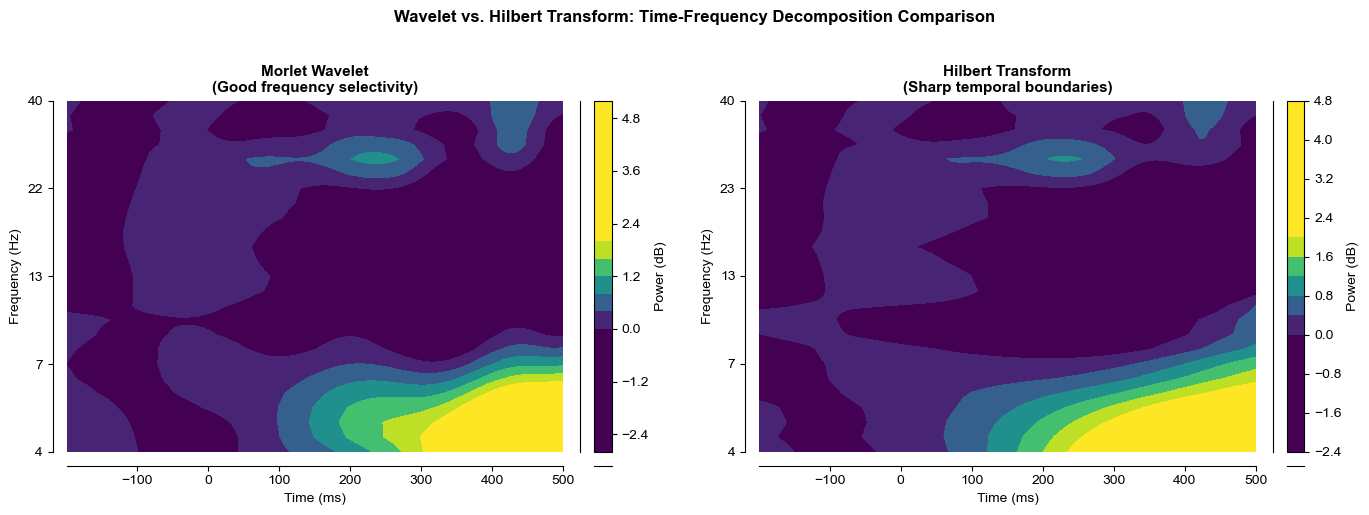

✓ Method comparison visualization complete


In [6]:
# Side-by-side comparison visualization using plot_tfr_timecourse
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plt.suptitle('Wavelet vs. Hilbert Transform: Time-Frequency Decomposition Comparison', 
             fontsize=12, fontweight='bold', y=1.02)

# Left subplot: Morlet (Wavelet)
plt.sca(axes[0])
plot_tfr_timecourse(
    tfr=tfr_morlet,
    elec_oi=['Fp1', 'Fp2', 'AF3', 'AF4'],
    timecourse='2d',
    contour=True,
    levels=20,
    cmap='viridis',
    vmin=0,
    vmax=2,
    onset_times=[0]
)
axes[0].set_title('Morlet Wavelet\n(Good frequency selectivity)', fontsize=11, fontweight='bold')

# Right subplot: Hilbert (Analytic Signal)
plt.sca(axes[1])
plot_tfr_timecourse(
    tfr=tfr_hilbert,
    elec_oi=['Fp1', 'Fp2', 'AF3', 'AF4'],
    timecourse='2d',
    contour=True,
    levels=20,
    cmap='viridis',
    vmin=0,
    vmax=2,
    onset_times=[0]
)
axes[1].set_title('Hilbert Transform\n(Sharp temporal boundaries)', fontsize=11, fontweight='bold')

plt.tight_layout()
display(fig)
plt.close()

print("✓ Method comparison visualization complete")

---

## Section 4: Multi-Subject Condition Comparisons with Statistical Testing

**Research Question**: Do condition effects on time-frequency signatures generalize across subjects? Where are effects statistically significant?

**Key concept**: Individual TFR patterns vary due to anatomy, habituation, and noise. To establish robust findings, aggregate effects across subjects and apply statistical tests.

**Approach**:
1. **Loop over subjects** (1-7 in this dataset)
2. **Compute condition comparison** for each subject (e.g., main task vs. localizer)
3. **Extract metric of interest** (e.g., alpha band power, lateralization index)
4. **Aggregate across subjects** and visualize grand average
5. **Apply statistical test** (e.g., paired t-tests, permutation tests) for significance

**Example metric**: **Condition effect** = (Main task alpha power) - (Localizer alpha power)
- If Main > Localizer → task increases alpha (unexpected; usually alpha suppresses with attention)
- If Main < Localizer → task suppresses alpha more (expected; active task drives alpha reduction)

### Your Task
Implement multi-subject analysis:
1. Loop over `[1, 2, 3, 4, 5, 6, 7]` (or subset of available subjects)
2. For each subject, compute TFR for 'main' and 'localizer' conditions
3. Extract alpha band (8-12 Hz) power for each condition
4. Calculate difference: `alpha_diff = main_alpha - localizer_alpha`
5. Store results in a dataframe: columns = ['subject', 'time', 'frequency', 'alpha_diff']
6. Visualize: Grand average difference with error bars (SEM) or confidence intervals
7. Statistical test: Paired t-test to test if alpha_diff significantly differs from zero

**Hints**:
- Use `try-except` blocks to skip subjects with missing/corrupted data
- Store each subject's data in a dictionary for flexible aggregation
- Consider baseline differences between subjects (use z-scores?)
- Use `scipy.stats.ttest_1samp()` for single-sample t-test against zero

In [7]:
for subject_id in range(1, 8):
    try:
        # Load data for this subject
        df_sj, epochs_sj = FolderStructure().load_processed_epochs(
            subject_id, 'ses_01_main', 'main', eye_dict
        )
        # Flag high-density (target+distractor present) vs low-density (both absent) displays
        df_sj.loc[(df_sj.target_presence != 'absent') & (df_sj.distractor_presence == 'absent'), 'display_type'] =  'T+D+'
        df_sj.loc[(df_sj.target_presence == 'absent') & (df_sj.distractor_presence == 'absent'), 'display_type'] =  'T-D-'

        sj_tfr = TFR(
            sj=subject_id,
            epochs=epochs_sj,
            df=df_sj,
            min_freq=4,                # Start from theta band (4 Hz)
            max_freq=40,               # Up to low gamma (40 Hz)
            num_frex=25,               # 25 frequencies between 4-40 Hz
            cycle_range=(3, 10),       # Standard wavelet cycles (balanced resolution trade-off)
            freq_scaling='log',        # Logarithmic frequency spacing
            baseline=(-0.2, 0),        # Baseline period: -200 to 0 ms pre-stimulus
            method='wavelet',          # Morlet wavelet decomposition
            base_method='cnd_spec',    # Condition-specific baseline correction
            downsample=2               # Downsample by factor of 2
        )

        tfr_result = sj_tfr.condition_tfrs(
            pos_labels=None,                            # No position-based lateralization for this comparison
            cnds={'display_type': ['T+D+', 'T-D-']},    # High- vs low-density displays
            elec_oi=['PO3','PO4','O1','O2','Pz'],       # Occipital electrodes
            window_oi=(-0.2, 0.5),                      # Analysis window: -200 to 500 ms
            f_name='display_density'                    # Analysis identifier for saved output
        )
    except Exception as e:
        print(f'  ✗ Subject {subject_id} failed: {str(e)}')

print('\n✓ All subjects processed')

Reading /Users/dvm/Library/CloudStorage/OneDrive-VrijeUniversiteitAmsterdam/projects/openDvM/eeg/processed/sub_01_ses_01_main-epo.fif ...
    Found the data of interest:
        t =    -699.22 ...    1000.00 ms
        0 CTF compensation matrices available
Adding metadata with 19 columns
2891 matching events found
No baseline correction applied
0 projection items activated
42 trials missing eyetracking
data (used eog instead)
Eye exclusion info saved in preprocessing file (session 01)
No topography info specified. For lateralization analysis, it is assumed as if all stimuli of interest are presented right (i.e., left  hemifield
Decomposing condition 1: T+D+ 

Decomposing condition 2: T-D-  channels

saving tfr for condition: T+D+ channels
Overwriting existing file.
saving tfr for condition: T-D-
Overwriting existing file.
Reading /Users/dvm/Library/CloudStorage/OneDrive-VrijeUniversiteitAmsterdam/projects/openDvM/eeg/processed/sub_02_ses_01_main-epo.fif ...
    Found the data of intere

In [8]:
# Load aggregated tfr results across all subjects
print('\nLoading tfr data...')
tfr_data = FolderStructure().read_tfr(
    tfr_folder_path=['wavelet'],  
    tfr_name='display_density',                 # From display density analysis
    cnds = ['T+D+', 'T-D-'],
    sjs='all'                                    # All subjects
)
print('✓ Data loaded')



Loading tfr data...
Reading /Users/dvm/Library/CloudStorage/OneDrive-VrijeUniversiteitAmsterdam/projects/openDvM/tfr/wavelet/sub_01_display_density_T+D+-tfr.h5 ...
Reading /Users/dvm/Library/CloudStorage/OneDrive-VrijeUniversiteitAmsterdam/projects/openDvM/tfr/wavelet/sub_02_display_density_T+D+-tfr.h5 ...
Reading /Users/dvm/Library/CloudStorage/OneDrive-VrijeUniversiteitAmsterdam/projects/openDvM/tfr/wavelet/sub_03_display_density_T+D+-tfr.h5 ...
Reading /Users/dvm/Library/CloudStorage/OneDrive-VrijeUniversiteitAmsterdam/projects/openDvM/tfr/wavelet/sub_04_display_density_T+D+-tfr.h5 ...
Reading /Users/dvm/Library/CloudStorage/OneDrive-VrijeUniversiteitAmsterdam/projects/openDvM/tfr/wavelet/sub_05_display_density_T+D+-tfr.h5 ...
Reading /Users/dvm/Library/CloudStorage/OneDrive-VrijeUniversiteitAmsterdam/projects/openDvM/tfr/wavelet/sub_06_display_density_T+D+-tfr.h5 ...
Reading /Users/dvm/Library/CloudStorage/OneDrive-VrijeUniversiteitAmsterdam/projects/openDvM/tfr/wavelet/sub_07_dis

not enough colors specified. Using default colors
Times converted from seconds to milliseconds
not enough colors specified. Using default colors
Times converted from seconds to milliseconds
not enough colors specified. Using default colors
Times converted from seconds to milliseconds


/var/folders/jd/_5gm34_n44x5fnp2_hdy7_1m0000gn/T/ipykernel_96719/2835731035.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


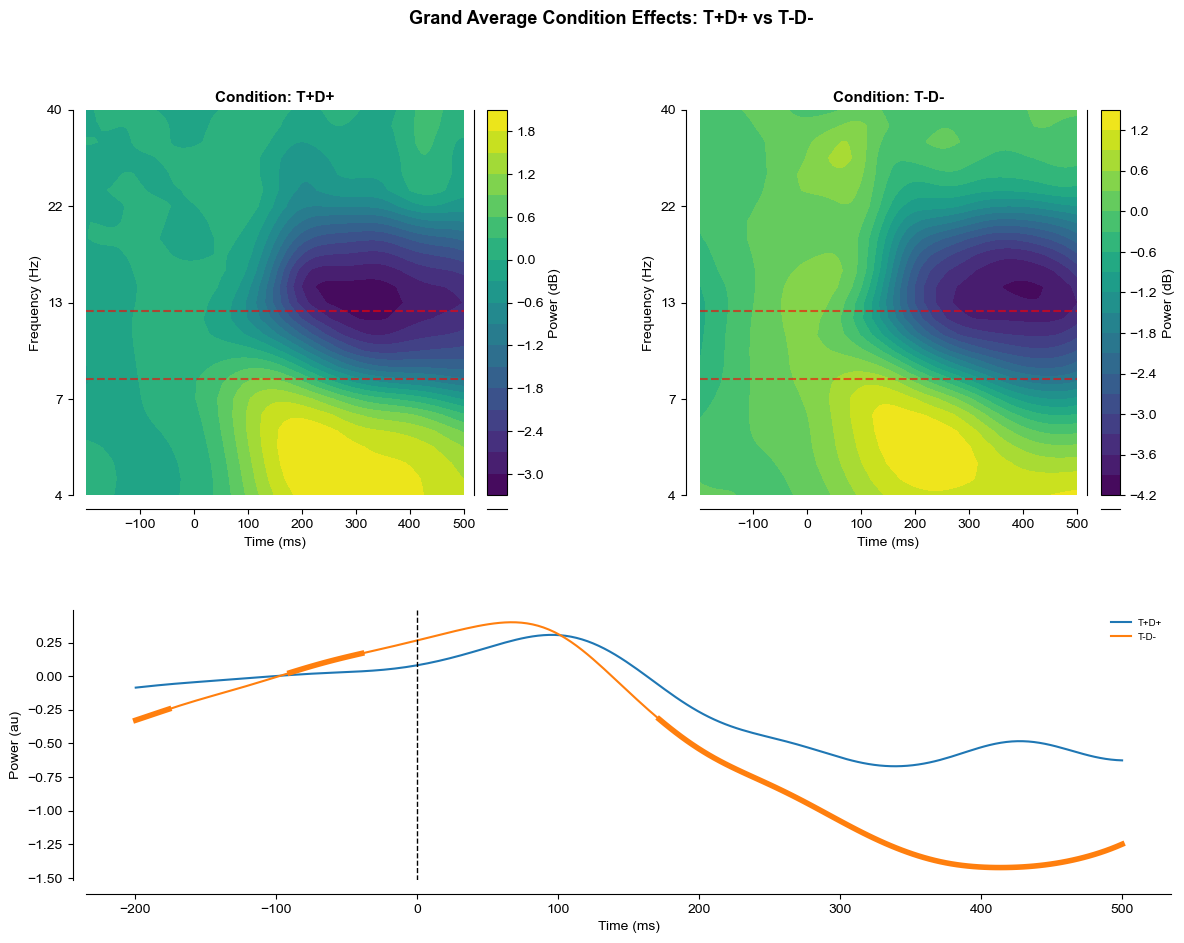

✓ Grand average visualization complete


In [9]:
# Visualize condition effects: spectrograms + alpha timecourse
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 0.7], hspace=0.35, wspace=0.3)
axes = [fig.add_subplot(gs[0, 0]), 
        fig.add_subplot(gs[0, 1]),
        fig.add_subplot(gs[1, :])]

plt.suptitle('Grand Average Condition Effects: T+D+ vs T-D-', 
             fontsize=13, fontweight='bold', y=0.98)

# Get channel names from one of the TFR objects
elec_names = tfr_data['T+D+'][0].ch_names

# ===== Top row: 2D spectrograms =====
conditions = ['T+D+', 'T-D-']
for idx, cnd in enumerate(conditions):
    plt.sca(axes[idx])
    plot_tfr_timecourse(
        tfr=tfr_data,
        cnds = [cnd],
        elec_oi=list(elec_names),
        timecourse='2d',
        contour=True,
        levels=20,
        cmap='viridis',
        vmin=None,
        vmax=None,
        onset_times=[0]
    )
    axes[idx].set_title(f'Condition: {cnd}', fontsize=11, fontweight='bold')
    axes[idx].axhline(8, color='red', linestyle='--', linewidth=1.5, alpha=0.6, label='Alpha band')
    axes[idx].axhline(12, color='red', linestyle='--', linewidth=1.5, alpha=0.6)

# ===== Bottom row: 1D alpha timecourse =====
plt.sca(axes[2])
plot_tfr_timecourse(
    tfr=tfr_data,
    cnds = conditions,
    elec_oi=list(elec_names),
    timecourse='1d',
    stats = 'fdr',
    onset_times=[0]
)

plt.tight_layout()
display(fig)
plt.close()

print("✓ Grand average visualization complete")

---

## Section 5: Summary and Next Steps

### Section 2: Wavelet Parameter Exploration
- Wavelet **cycle range** controls the temporal-frequency resolution trade-off
- Fewer cycles (3-8): Better temporal precision for event-locked components
- More cycles (4-12): Better frequency selectivity for narrowband oscillations
- Standard (3-10) provides a good default balance

### Section 3: Method Comparison
- **Morlet wavelets**: Smooth spectral transitions, excellent frequency selectivity
- **Hilbert transform**: Sharper temporal boundaries, requires pre-filtering
- Choice depends on your research question and data characteristics
- The TFR class supports dynamic method switching for easy comparison

### Section 4: Multi-Subject Generalization
- Individual TFR patterns vary substantially across subjects (anatomy, habituation, task engagement)
- Grand average aggregation reveals robust population effects
- Statistical testing (FDR-corrected) identifies time-frequency regions with significant condition effects
- Spectrograms + 1D timecourse visualization effectively communicates both detail and summary

### Best Practices for TFR Analysis
1. **Always visualize**: Spectrograms reveal patterns that summary statistics miss
2. **Check assumptions**: Verify baseline periods, stationarity, and condition balance
3. **Consider multiple methods**: Wavelets, Hilbert, and other decompositions offer different perspectives
4. **Aggregate across subjects**: Single-subject findings may not generalize
5. **Report effect sizes**: p-values alone are insufficient; include Cohen's d, eta-squared, or similar
6. **Account for multiple comparisons**: FDR or Bonferroni correction is essential for time-frequency data

### Next Steps
- Explore **lateralization effects** using topo_flip (see `03_tfr_analysis.ipynb`)
- Implement **frequency-band differences** (e.g., alpha vs. theta)
- Apply **permutation testing** for robust non-parametric inference
- Examine **inter-subject variability** as a feature of individual differences
- Consider **source localization** (e.g., inverse models) if spatial resolution is critical